In [1]:
# Change dir
import os
os.chdir('/Users/seandickson/JohnsHopkinsScripts/CreatingAIEnabledSystems/ironclad-Sean090900/ironclad')

In [2]:
import numpy as np
from PIL import Image, ImageStat
from modules.extraction.preprocessing import Preprocessing
from modules.extraction.embedding import Embedding
from modules.retrieval.index.bruteforce import FaissBruteForce
from modules.retrieval.index.hnsw import FaissHNSW
from modules.retrieval.index.lsh import FaissLSH
from modules.retrieval.search import FaissSearch

print('DONE')

DONE


In [3]:
## List of designed parameters: 
N = 13
MODEL = 'casia-webface'             # Variable
INDEX = 'bruteforce'                # Constant
SIMILARITY_MEASURE = 'cosine'       # Constant: euclidean

# Object Initialization
preprocessor = Preprocessing()
model = Embedding(MODEL)
index = FaissBruteForce.load(f'storage/embeddings/{MODEL}/faiss_{INDEX}_{MODEL}_cosine_index.pkl')
search = FaissSearch(index, metric=SIMILARITY_MEASURE)

In [13]:
def calculate_avg_prec_at_k(goal, meta_results):
    # Parse name
    name = goal.split('_')[0] + '_' + goal.split('_')[1]
    # Calculate
    correct = 0
    sum_precisions = 0
    for i in range(len(meta_results)):
        result = meta_results[i]
        if name in result:
            correct += 1
            sum_precisions += correct / (i + 1)
    # Return value
    if correct == 0:
        return 0
    return sum_precisions / correct

def tta_embedding(model, preprocessor, img):
    aug_imgs_tensors = [preprocessor.process(img), preprocessor.process(img.transpose(Image.FLIP_LEFT_RIGHT))]
    embs = [model.encode(aug) for aug in aug_imgs_tensors]
    emb = np.mean(embs, axis=0)
    return emb / np.linalg.norm(emb)

In [15]:
probe_path = 'storage/probe/'
sum = 0
count = 0

# scores = {}
scores = {
    'probe_mode': [],
    'probe_format': [],
    'probe_jfif': [],
    'probe_jfif_unit': [],
    'probe_jfif_density': [],
    'probe_brightness': [],
    'probe_contrast': [],
    'name': [],
    'distances': [],
    'meta_results': [],
    'query_vector': [],
    'mAP@K_score': [],
}

for image_set in os.listdir(probe_path):
    if image_set != 'sample_gallery.py':
        for image_name in os.listdir(probe_path + '/' + image_set):
            path = probe_path + '/' + image_set + '/' + image_name
            image = Image.open(path)
            # processed_tensor = preprocessor.process(image)
            # query_vector = model.encode(processed_tensor)
            tta_query_vector = tta_embedding(model, preprocessor, image)
            distances, indices, meta_results = search.search(tta_query_vector, k=N)
            avg_prec_at_k = calculate_avg_prec_at_k(str(image_name), meta_results)
            
            # h, w = image.size
            mode = image.mode
            format = image.format
            jfif = image.info['jfif']
            jfif_unit = image.info['jfif_unit']
            jfif_density = image.info['jfif_density']
            # Convert to grayscale for analysis
            gray = image.convert("L")
            arr = np.array(gray)

            # Brightness (mean pixel intensity)
            brightness = arr.mean()

            # Contrast (standard deviation)
            contrast = arr.std()

            # Add to scores
            scores['probe_mode'].append(mode)
            scores['probe_format'].append(format)
            scores['probe_jfif'].append(jfif)
            scores['probe_jfif_unit'].append(jfif_unit)
            scores['probe_jfif_density'].append(jfif_density)
            scores['probe_brightness'].append(brightness)
            scores['probe_contrast'].append(contrast)
            scores['name'].append(image_name)
            scores['distances'].append(distances)
            scores['meta_results'].append(meta_results)
            scores['query_vector'].append(tta_query_vector)
            scores['mAP@K_score'].append(avg_prec_at_k)

            sum += avg_prec_at_k
            count += 1

avg = sum / count
print(f'Mean Average Precision @ k across full dataset: {avg}')

Mean Average Precision @ k across full dataset: 0.12074088976866751


In [ ]:
image = Image.open('storage/probe/Jacqueline_Obradors/Jacqueline_Obradors_0002.jpg')
h, w = image.size
mode = image.mode
format = image.format

jfif = image.info['jfif']
jfif_unit = image.info['jfif_unit']
jfif_density = image.info['jfif_density']

# Convert to grayscale for analysis
gray = image.convert("L")
arr = np.array(gray)

# Brightness (mean pixel intensity)
brightness = arr.mean()

# Contrast (standard deviation)
contrast = arr.std()

# probe_stats = ImageStat.Stat(Image.open('storage/probe/Jacqueline_Obradors/Jacqueline_Obradors_0002.jpg'))
# scores['probe_R_stddev'] = probe_stats.stddev[0]
# probe_stats.count
# probe_stats.extrema
# probe_stats.var
# probe_stats.rms

53.82681604418318

In [184]:
import pandas as pd

df = pd.DataFrame(scores)
df = df.sort_values(by='mAP@K_score', ascending=False)

# AVG Dist
df['avg_distance'] = df['distances'].apply(lambda x: np.mean(x))

# Conver distances to multiple features
df['nn_1_dist'] = df['distances'].apply(lambda x: x[0][0])
df['nn_2_dist'] = df['distances'].apply(lambda x: x[0][1])
df['nn_3_dist'] = df['distances'].apply(lambda x: x[0][2])
df['nn_4_dist'] = df['distances'].apply(lambda x: x[0][3])
df['nn_5_dist'] = df['distances'].apply(lambda x: x[0][4])

df = df.drop('probe_jfif_density', axis=1)
df

,probe_mode,probe_format,probe_jfif,probe_jfif_unit,probe_brightness,probe_contrast,name,distances,meta_results,query_vector,mAP@K_score,avg_distance,nn_1_dist,nn_2_dist,nn_3_dist,nn_4_dist,nn_5_dist
861,RGB,JPEG,257,0,41.063392,53.826816,Jacqueline_Obradors_0002.jpg,"[[0.07553742, 0.1244033, 0.12809356, 0.1282916...","[Jacqueline_Obradors_0001.jpg, Kalpana_Chawla_...","[-0.02556777, 0.016223636, 0.0795419, -0.02022...",1.0,0.132326,0.075537,0.124403,0.128094,0.128292,0.129405
314,RGB,JPEG,257,0,88.031104,53.319158,Isabelle_Huppert_0002.jpg,"[[0.20479047, 0.25524747, 0.25576374, 0.292626...","[Isabelle_Huppert_0001.jpg, Reese_Witherspoon_...","[0.0104102045, 0.034841247, 0.088998854, 0.009...",1.0,0.300766,0.204790,0.255247,0.255764,0.292627,0.295420
913,RGB,JPEG,257,0,112.305232,79.044726,Megawati_Sukarnoputri_0002.jpg,"[[0.12949324, 0.13245603, 0.1390756, 0.1413641...","[Megawati_Sukarnoputri_0001.jpg, Hu_Jintao_000...","[0.012011031, 0.019544005, 0.072882906, -0.020...",1.0,0.145094,0.129493,0.132456,0.139076,0.141364,0.142235
804,RGB,JPEG,257,0,75.623952,72.306521,Sean_Patrick_OMalley_0002.jpg,"[[0.2883501, 0.4073214, 0.40884906, 0.46050566...","[Sean_Patrick_OMalley_0001.jpg, Gunter_Pleuger...","[0.030172426, 0.012902589, 0.07873958, -0.0322...",1.0,0.466909,0.288350,0.407321,0.408849,0.460506,0.462603
253,RGB,JPEG,257,0,112.529920,69.674294,Margaret_Thatcher_0002.jpg,"[[0.500136, 0.53797287, 0.57315373, 0.5798974,...","[Margaret_Thatcher_0001.jpg, Spencer_Abraham_0...","[-0.028728552, 0.01221978, 0.03377741, -0.0227...",1.0,0.597758,0.500136,0.537973,0.573154,0.579897,0.590414
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
388,RGB,JPEG,257,0,63.541232,60.791067,Vicente_Fernandez_0002.jpg,"[[0.22512752, 0.24427445, 0.29141456, 0.296005...","[Christina_Aguilera_0001.jpg, Heidi_Fleiss_000...","[0.020252356, 0.0745291, 0.032100353, -0.00818...",0.0,0.294661,0.225128,0.244274,0.291415,0.296005,0.297800
389,RGB,JPEG,257,0,96.361200,77.973835,Tim_Floyd_0002.jpg,"[[0.14110683, 0.14642504, 0.14783153, 0.149948...","[Kalpana_Chawla_0002.jpg, Thaksin_Shinawatra_0...","[0.01806772, 0.028968362, 0.054518856, -0.0067...",0.0,0.155791,0.141107,0.146425,0.147832,0.149949,0.150360
390,RGB,JPEG,257,0,95.099120,83.892842,Franko_Simatovic_0002.jpg,"[[0.18769872, 0.19376907, 0.19723648, 0.211015...","[Hun_Sen_0003.jpg, Jamling_Norgay_0001.jpg, Ja...","[0.019241476, -0.0037890694, 0.069256924, -0.0...",0.0,0.212714,0.187699,0.193769,0.197236,0.211015,0.213847
391,RGB,JPEG,257,0,91.651888,53.908034,Patricia_Heaton_0002.jpg,"[[0.18192494, 0.19617313, 0.19852015, 0.200521...","[Sachiko_Yamada_0001.jpg, Heizo_Takenaka_0007....","[0.006978619, 0.057922777, 0.09089205, -0.0048...",0.0,0.206586,0.181925,0.196173,0.198520,0.200522,0.201916


In [185]:

import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Encode categorical columns
cat_cols = ['probe_mode', 'probe_format', 'probe_jfif', 'probe_jfif_unit', 'name']
for c in cat_cols:
    df[c] = LabelEncoder().fit_transform(df[c].astype(str))

# Drop columns that are not scalar features (like vectors, meta_results)
df = df.drop(columns=['meta_results', 'query_vector', 'distances'], errors='ignore')

df

,probe_mode,probe_format,probe_jfif,probe_jfif_unit,probe_brightness,probe_contrast,name,mAP@K_score,avg_distance,nn_1_dist,nn_2_dist,nn_3_dist,nn_4_dist,nn_5_dist
861,0,0,0,0,41.063392,53.826816,452,1.0,0.132326,0.075537,0.124403,0.128094,0.128292,0.129405
314,0,0,0,0,88.031104,53.319158,443,1.0,0.300766,0.204790,0.255247,0.255764,0.292627,0.295420
913,0,0,0,0,112.305232,79.044726,744,1.0,0.145094,0.129493,0.132456,0.139076,0.141364,0.142235
804,0,0,0,0,75.623952,72.306521,910,1.0,0.466909,0.288350,0.407321,0.408849,0.460506,0.462603
253,0,0,0,0,112.529920,69.674294,706,1.0,0.597758,0.500136,0.537973,0.573154,0.579897,0.590414
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
388,0,0,0,0,63.541232,60.791067,973,0.0,0.294661,0.225128,0.244274,0.291415,0.296005,0.297800
389,0,0,0,0,96.361200,77.973835,951,0.0,0.155791,0.141107,0.146425,0.147832,0.149949,0.150360
390,0,0,0,0,95.099120,83.892842,329,0.0,0.212714,0.187699,0.193769,0.197236,0.211015,0.213847
391,0,0,0,0,91.651888,53.908034,814,0.0,0.206586,0.181925,0.196173,0.198520,0.200522,0.201916


In [186]:
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

X = df.drop(columns=['mAP@K_score'])
y = df['mAP@K_score']

model = make_pipeline(StandardScaler(), RidgeCV(alphas=[0.1, 1.0, 10.0]))
model.fit(X, y)

# Get feature coefficients
coefs = model.named_steps['ridgecv'].coef_
feature_importance = pd.Series(coefs, index=X.columns).sort_values()

print(feature_importance)

nn_1_dist          -0.502234
nn_5_dist          -0.280272
nn_3_dist          -0.205190
probe_brightness   -0.009743
probe_mode          0.000000
probe_format        0.000000
probe_jfif          0.000000
probe_jfif_unit     0.000000
probe_contrast      0.004695
name                0.015058
nn_2_dist           0.029205
nn_4_dist           0.081056
avg_distance        0.904981
dtype: float64


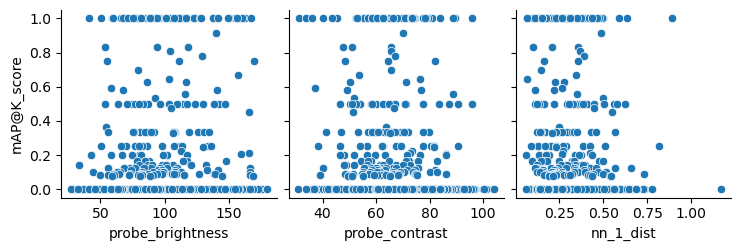

In [189]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df, y_vars=['mAP@K_score'], x_vars=['probe_brightness', 'probe_contrast', 'nn_1_dist'])
plt.show()